In [ ]:
!pip install h5py --quiet
import h5py


In [ ]:
# Install packages
!pip install torch torchvision torchaudio --quiet
!pip install numpy pandas matplotlib seaborn scikit-learn scipy --quiet
!pip install kagglehub --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("✅ Setup complete!")


🚀 Using device: cuda
   GPU: NVIDIA A100-SXM4-80GB
   Memory: 85.17 GB
✅ Setup complete!


In [ ]:
import kagglehub

print("📥 Downloading Kaggle dataset...")
print("   This may take 5-10 minutes (97K files)")

# Download dataset
dataset_path = kagglehub.dataset_download("nguyenngonhatnam/wifipose-dataset")

print(f"\n✅ Dataset downloaded to: {dataset_path}")

# Verify structure
print("\n📂 Dataset structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Show first 3 files
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files) - 3} more files')
    if level > 2:  # Limit depth
        break

print(f"\n✅ Dataset ready! Path: {dataset_path}")

📥 Downloading Kaggle dataset...
   This may take 5-10 minutes (97K files)
Using Colab cache for faster access to the 'wifipose-dataset' dataset.

✅ Dataset downloaded to: /kaggle/input/wifipose-dataset

📂 Dataset structure:
wifipose-dataset/
  test_data/
    test_data_list.txt
    keypoint/
      S21_04_336.npy
      S53_09_314.npy
      S12_48_335.npy
      ... and 7821 more files
    csi/
      S51_12_334.mat
      S11_09_341.mat
      S12_23_338.mat
      ... and 7821 more files
  train_data/
    train_data_list.txt
    keypoint/
      S22_32_524.npy
      S53_46_413.npy
      S11_03_228.npy
      ... and 89943 more files
    csi/
      S53_46_124.mat
      S23_47_230.mat
      S51_02_299.mat
      ... and 89943 more files

✅ Dataset ready! Path: /kaggle/input/wifipose-dataset


In [ ]:
class CSIEncoder(nn.Module):
  """Encodes WiFi CSI signals (amplitude + phase) into feature representations"""
  def __init__(self, num_subcarriers=52, embedding_dim=256):
      super().__init__()
      self.encoder = nn.Sequential(
          nn.Linear(num_subcarriers * 2, 512),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(512, embedding_dim),
          nn.ReLU(),
          nn.Dropout(0.3)
      )

  def forward(self, x):
      return self.encoder(x)


class DensePoseNet(nn.Module):
  """Maps CSI features to DensePose UV coordinates for 24 body parts"""
  def __init__(self, embedding_dim=256, num_parts=24):
      super().__init__()
      self.num_parts = num_parts

      encoder_layer = nn.TransformerEncoderLayer(
          d_model=embedding_dim,
          nhead=8,
          dim_feedforward=512,
          dropout=0.1,
          batch_first=True
      )
      self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

      self.uv_predictor = nn.Sequential(
          nn.Linear(embedding_dim, 512),
          nn.ReLU(),
          nn.Dropout(0.2),
          nn.Linear(512, num_parts * 2)
      )

      self.confidence_predictor = nn.Sequential(
          nn.Linear(embedding_dim, 256),
          nn.ReLU(),
          nn.Linear(256, num_parts),
          nn.Sigmoid()
      )

  def forward(self, csi_features):
      features = self.transformer(csi_features)
      last_features = features[:, -1, :]

      uv_coords = self.uv_predictor(last_features)
      uv_coords = torch.tanh(uv_coords)
      uv_coords = uv_coords.view(-1, self.num_parts, 2)

      confidence = self.confidence_predictor(last_features)

      return uv_coords, confidence


class ActionRecognitionNet(nn.Module):
  """Temporal model for security action classification"""
  def __init__(self, embedding_dim=256, num_classes=4):
      super().__init__()
      self.temporal_conv = nn.Sequential(
          nn.Conv1d(embedding_dim, 512, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.MaxPool1d(2),
          nn.Conv1d(512, 256, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.AdaptiveMaxPool1d(1)
      )

      self.classifier = nn.Sequential(
          nn.Linear(256, 128),
          nn.ReLU(),
          nn.Dropout(0.5),
          nn.Linear(128, num_classes)
      )

  def forward(self, csi_features):
      x = csi_features.permute(0, 2, 1)
      x = self.temporal_conv(x)
      x = x.squeeze(-1)
      logits = self.classifier(x)
      return logits


class WiFiDensePoseSystem(nn.Module):
  """Complete end-to-end system"""
  def __init__(self, num_subcarriers=52, embedding_dim=256,
                num_parts=24, num_classes=4):
      super().__init__()
      self.csi_encoder = CSIEncoder(num_subcarriers, embedding_dim)
      self.densepose_net = DensePoseNet(embedding_dim, num_parts)
      self.action_net = ActionRecognitionNet(embedding_dim, num_classes)

  def forward(self, csi_data):
      csi_features = self.csi_encoder(csi_data)
      uv_coords, confidence = self.densepose_net(csi_features)
      action_logits = self.action_net(csi_features)

      return {
          'uv_coords': uv_coords,
          'confidence': confidence,
          'action_logits': action_logits
      }


# Initialize model
model = WiFiDensePoseSystem(
  num_subcarriers=52,
  embedding_dim=256,
  num_parts=24,
  num_classes=4
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model initialized!")
print(f"   Total parameters: {total_params:,}")
print(f"   Model size: ~{total_params * 4 / 1e6:.2f} MB")


✅ Model initialized!
   Total parameters: 3,342,284
   Model size: ~13.37 MB


In [ ]:
!pip install torchviz

In [ ]:
import torch
from torchviz import make_dot

# Assuming the classes provided in your prompt are already defined above...

# 1. Instantiate Model
device = torch.device('cpu') # Visualization is easier on CPU
model = WiFiDensePoseSystem().to(device)

# 2. Create Dummy Input (Batch=1, Time=30, Features=104)
dummy_input = torch.randn(1, 30, 104).to(device)

# 3. Forward Pass to build graph
output = model(dummy_input)

# 4. Generate Visualization
# We use a tuple of outputs to visualize all branches
vis_graph = make_dot(
    (output['uv_coords'], output['confidence'], output['action_logits']),
    params=dict(model.named_parameters()),
    show_attrs=True,
    show_saved=True
)

# 5. Save
vis_graph.format = 'png'
vis_graph.render("wifi_densepose_architecture")
print("Architecture diagram saved as wifi_densepose_architecture.png")


Architecture diagram saved as wifi_densepose_architecture.png


In [ ]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import numpy as np
import scipy.io as sio
import h5py

class KaggleWiFiPoseDataset(Dataset):
    """
    Data loader for Kaggle wifipose-dataset.
    - Loads CSI from .mat files using h5py.
    - Loads keypoints from .npy files.
    - Generates action labels from ground-truth keypoint motion (Option 2).
    """

    def __init__(self, data_dir, split='train_data', seq_len=30):
        self.data_dir = Path(data_dir)
        self.split = split
        self.seq_len = seq_len
        self.action_names = ['Normal', 'Loitering', 'Running', 'Aggressive']

        split_dir = self.data_dir / self.split
        self.csi_dir = split_dir / "csi"
        self.kpt_dir = split_dir / "keypoint"
        list_file = split_dir / f"{self.split}_list.txt"

        if not self.csi_dir.exists() or not self.kpt_dir.exists():
            raise FileNotFoundError(f"Expected 'csi' and 'keypoint' folders under {split_dir}")

        if not list_file.exists():
            raise FileNotFoundError(f"List file not found: {list_file}")

        with open(list_file, "r") as f:
            ids = [line.strip() for line in f if line.strip()]

        self.ids = []
        for sid in ids:
            mat_path = self.csi_dir / f"{sid}.mat"
            kpt_path = self.kpt_dir / f"{sid}.npy"
            if mat_path.exists() and kpt_path.exists():
                self.ids.append(sid)

        if len(self.ids) == 0:
            raise RuntimeError(f"No samples found in {split_dir}/csi and {split_dir}/keypoint")

        print(f"✅ Found {len(self.ids)} samples in {self.split} set")

    def _load_csi(self, sid):
        mat_path = self.csi_dir / f"{sid}.mat"
        with h5py.File(mat_path, "r") as f:
            if "csi_serial" in f:
                dset = f["csi_serial"]
            else:
                keys = [k for k in f.keys()]
                dset = f[keys[0]]
            csi = np.array(dset)

        if csi.dtype.fields and "real" in csi.dtype.fields and "imag" in csi.dtype.fields:
            csi = csi["real"] + 1j * csi["imag"]
            amp = np.abs(csi)
            phs = np.angle(csi)
            csi = np.concatenate([amp, phs], axis=-1)

        if csi.ndim >= 3:
            csi = csi.reshape(csi.shape[0], -1)

        if csi.shape[1] > 104:
            csi = csi[:, :104]
        elif csi.shape[1] < 104:
            pad = np.zeros((csi.shape[0], 104 - csi.shape[1]), dtype=csi.dtype)
            csi = np.concatenate([csi, pad], axis=1)

        return csi.astype(np.float32)

    def _load_keypoint(self, sid):
        kpt_path = self.kpt_dir / f"{sid}.npy"
        keypoints = np.load(kpt_path)
        if keypoints.ndim == 4: keypoints = keypoints[:, 0, :, :]
        uv = keypoints[..., :2]
        uv_max = np.abs(uv).max()
        if uv_max > 0: uv = uv / (uv_max * 2)
        num_parts = uv.shape[1]
        if num_parts < 24:
            pad = np.zeros((uv.shape[0], 24 - num_parts, 2), dtype=uv.dtype)
            uv = np.concatenate([uv, pad], axis=1)
        elif num_parts > 24:
            uv = uv[:, :24, :]
        return np.clip(uv, -1, 1).astype(np.float32)

    def _infer_action_label(self, uv_seq):
        """
        ====================================================================
        CHANGED: Infer action from Ground Truth Keypoint motion.
        This is more accurate than using CSI heuristics.
        ====================================================================
        """
        if uv_seq.shape[0] < 2: return 0

        motion_per_joint = np.sqrt(np.sum(np.diff(uv_seq, axis=0)**2, axis=-1))
        avg_velocity = np.mean(motion_per_joint)
        max_velocity = np.max(motion_per_joint)

        # Heuristics based on pose dynamics (tuned for normalized coordinates)
        if avg_velocity > 0.02: return 2  # Running (High sustained movement)
        if avg_velocity < 0.002: return 1 # Loitering (Very low movement)
        if max_velocity > 0.05: return 3  # Aggressive (Sudden, sharp limb movement)
        return 0 # Normal (Walking, moderate movement)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]
        csi_data = self._load_csi(sid)
        uv_seq = self._load_keypoint(sid)

        T = csi_data.shape[0]
        if T >= self.seq_len:
            start = np.random.randint(0, T - self.seq_len + 1)
            csi_seq = csi_data[start:start + self.seq_len]
            uv_seq_window = uv_seq[start:start + self.seq_len]
        else:
            pad_len = self.seq_len - T
            csi_seq = np.pad(csi_data, ((0, pad_len), (0, 0)), mode='edge')
            uv_seq_window = np.pad(uv_seq, ((0, pad_len), (0, 0), (0, 0)), mode='edge')

        # === CHANGED: Generate label from keypoint motion ===
        action_label = self._infer_action_label(uv_seq_window)
        uv_mean = uv_seq_window.mean(axis=0)

        return {
            'csi': csi_seq.astype(np.float32),
            'uv_coords': uv_mean.astype(np.float32),
            'action_label': action_label,
        }

# --- This part remains the same ---
print("📂 Loading Kaggle WiFi Pose datasets with Pose-Based Action Labels...")

try:
    data_root = "/kaggle/input/wifipose-dataset"

    train_dataset = KaggleWiFiPoseDataset(data_root, split='train_data', seq_len=30)
    test_dataset  = KaggleWiFiPoseDataset(data_root, split='test_data', seq_len=30)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    print("\n✅ Datasets loaded!")
    print(f"   Train: {len(train_dataset)} samples")
    print(f"   Test: {len(test_dataset)} samples")

except Exception as e:
    print(f"Error loading datasets: {e}")
    print("Make sure the Kaggle dataset was downloaded correctly.")



📂 Loading Kaggle WiFi Pose datasets with Pose-Based Action Labels...
✅ Found 89946 samples in train_data set
✅ Found 7824 samples in test_data set

✅ Datasets loaded!
   Train: 89946 samples
   Test: 7824 samples


In [ ]:
""" from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import numpy as np
import scipy.io as sio

class KaggleWiFiPoseDataset(Dataset):
    """Data loader for Kaggle wifipose-dataset (CSI .mat + keypoint .npy)."""

    def __init__(self, data_dir, split='train_data', seq_len=30):
        self.data_dir = Path(data_dir)
        self.split = split
        self.seq_len = seq_len
        self.action_names = ['Normal', 'Loitering', 'Running', 'Aggressive']

        split_dir = self.data_dir / self.split
        self.csi_dir = split_dir / "csi"
        self.kpt_dir = split_dir / "keypoint"
        list_file = split_dir / f"{self.split}_list.txt"

        if not self.csi_dir.exists() or not self.kpt_dir.exists():
            raise FileNotFoundError(f"Expected 'csi' and 'keypoint' folders under {split_dir}")

        if not list_file.exists():
            raise FileNotFoundError(f"List file not found: {list_file}")

        with open(list_file, "r") as f:
            ids = [line.strip() for line in f if line.strip()]

        self.ids = []
        for sid in ids:
            mat_path = self.csi_dir / f"{sid}.mat"
            kpt_path = self.kpt_dir / f"{sid}.npy"
            if mat_path.exists() and kpt_path.exists():
                self.ids.append(sid)

        if len(self.ids) == 0:
            raise RuntimeError(f"No samples found in {split_dir}/csi and {split_dir}/keypoint")

        print(f"✅ Found {len(self.ids)} samples in {self.split} set")

    def _load_csi(self, sid):
      mat_path = self.csi_dir / f"{sid}.mat"

      with h5py.File(mat_path, "r") as f:
          # Inspect once with: print(list(f.keys()))
          if "csi_serial" in f:
              dset = f["csi_serial"]
          else:
              keys = [k for k in f.keys()]
              dset = f[keys[0]]

          csi = np.array(dset)  # often structured with fields 'real' and 'imag'

      # If stored as structured array with fields 'real' and 'imag'
      if csi.dtype.fields is not None and "real" in csi.dtype.fields and "imag" in csi.dtype.fields:
          real = csi["real"]
          imag = csi["imag"]
          csi = real + 1j * imag          # complex array
          amp = np.abs(csi)               # amplitude
          phs = np.angle(csi)             # phase
          csi = np.concatenate([amp, phs], axis=-1)  # last dim = 2 * num_subcarriers

      # Flatten spatial dims: T × (features)
      if csi.ndim >= 3:
          T = csi.shape[0]
          csi = csi.reshape(T, -1)
      else:
          T = csi.shape[0]
          csi = csi.reshape(T, -1)

      # Keep 104 features (52 amp + 52 phase equivalent)
      if csi.shape[1] > 104:
          csi = csi[:, :104]
      elif csi.shape[1] < 104:
          pad = np.zeros((csi.shape[0], 104 - csi.shape[1]), dtype=csi.dtype)
          csi = np.concatenate([csi, pad], axis=1)

      return csi.astype(np.float32)



    def _load_keypoint(self, sid):
        kpt_path = self.kpt_dir / f"{sid}.npy"
        keypoints = np.load(kpt_path)

        # T x persons x joints x coords OR T x joints x coords
        if keypoints.ndim == 4:
            keypoints = keypoints[:, 0, :, :]  # first person

        if keypoints.shape[-1] >= 2:
            uv = keypoints[..., :2]
        else:
            uv = keypoints

        uv_max = np.abs(uv).max()
        if uv_max > 0:
            uv = uv / (uv_max * 2)

        num_parts = uv.shape[1]
        if num_parts < 24:
            padding = np.zeros((uv.shape[0], 24 - num_parts, 2), dtype=uv.dtype)
            uv = np.concatenate([uv, padding], axis=1)
        elif num_parts > 24:
            uv = uv[:, :24, :]

        return np.clip(uv, -1, 1).astype(np.float32)

    def _infer_action_label(self, csi_data):
        csi_diff = np.abs(np.diff(csi_data[:, :52], axis=0))
        mean_change = np.mean(csi_diff)
        std_change = np.std(csi_diff)
        max_change = np.max(csi_diff)

        if max_change > 8:
            return 3 if std_change > 3 else 2
        elif mean_change < 0.5:
            return 1
        else:
            return 0

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]
        csi_data = self._load_csi(sid)
        uv_seq = self._load_keypoint(sid)

        T = csi_data.shape[0]
        if T >= self.seq_len:
            start = np.random.randint(0, T - self.seq_len + 1)
            csi_seq = csi_data[start:start + self.seq_len]
            uv_seq = uv_seq[start:start + self.seq_len]
        else:
            pad_len = self.seq_len - T
            csi_seq = np.pad(csi_data, ((0, pad_len), (0, 0)), mode='edge')
            uv_seq = np.pad(uv_seq, ((0, pad_len), (0, 0), (0, 0)), mode='edge')

        uv_mean = uv_seq.mean(axis=0)
        action_label = self._infer_action_label(csi_seq)

        return {
            'csi': csi_seq.astype(np.float32),
            'uv_coords': uv_mean.astype(np.float32),
            'action_label': action_label
        }


print("📂 Loading Kaggle WiFi Pose datasets...")

try:
    data_root = "/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1"

    train_dataset = KaggleWiFiPoseDataset(data_root, split='train_data', seq_len=30)
    test_dataset  = KaggleWiFiPoseDataset(data_root, split='test_data', seq_len=30)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    print("\n✅ Datasets loaded!")
    print(f"   Train: {len(train_dataset)} samples")
    print(f"   Test: {len(test_dataset)} samples")

except Exception as e:
    print(f"Error loading datasets: {e}")
    print("Make sure the Kaggle dataset was downloaded correctly and list file / keys are correct.") """


SyntaxError: invalid syntax (ipython-input-2839908424.py, line 7)

In [ ]:
# ==============================================================================
# ENHANCED TRAINING LOOP: Separate Pose & Action Logging
# ==============================================================================

model = model.to(device)

pose_criterion = nn.L1Loss()
action_criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

num_epochs = 25 # Short diagnostic run
lambda_pose = 0.5   # Reduced weight as discussed
lambda_action = 1.0

# Storage for plotting
train_losses = []
val_losses = []
val_accuracies = []

# New: Separate logs
train_pose_losses = []
train_action_losses = []


def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    running_pose_loss = 0.0
    running_action_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        # Move data to device
        if isinstance(batch['csi'], torch.Tensor):
            csi = batch['csi'].to(device)
            uv_gt = batch['uv_coords'].to(device)
            labels = batch['action_label'].to(device)
        else:
            csi = torch.from_numpy(batch['csi']).to(device)
            uv_gt = torch.from_numpy(batch['uv_coords']).to(device)
            labels = torch.tensor(batch['action_label'], dtype=torch.long).to(device)

        optimizer.zero_grad()
        outputs = model(csi)

        uv_pred = outputs['uv_coords']
        action_logits = outputs['action_logits']

        # Calculate individual losses
        pose_loss = pose_criterion(uv_pred, uv_gt)
        action_loss = action_criterion(action_logits, labels)

        # Weighted sum
        loss = lambda_pose * pose_loss + lambda_action * action_loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Track statistics
        B = csi.size(0)
        running_loss += loss.item() * B
        running_pose_loss += pose_loss.item() * B
        running_action_loss += action_loss.item() * B

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch [{batch_idx+1}/{len(train_loader)}] | "
                  f"Total: {loss.item():.4f} | "
                  f"Pose: {pose_loss.item():.4f} | "
                  f"Action: {action_loss.item():.4f}")

    N = len(train_dataset)
    return (running_loss / N, running_pose_loss / N, running_action_loss / N)


def evaluate(loader, dataset_name='Val'):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch['csi'], torch.Tensor):
                csi = batch['csi'].to(device)
                uv_gt = batch['uv_coords'].to(device)
                labels = batch['action_label'].to(device)
            else:
                csi = torch.from_numpy(batch['csi']).to(device)
                uv_gt = torch.from_numpy(batch['uv_coords']).to(device)
                labels = torch.tensor(batch['action_label'], dtype=torch.long).to(device)

            outputs = model(csi)
            uv_pred = outputs['uv_coords']
            action_logits = outputs['action_logits']

            pose_loss = pose_criterion(uv_pred, uv_gt)
            action_loss = action_criterion(action_logits, labels)

            loss = lambda_pose * pose_loss + lambda_action * action_loss
            running_loss += loss.item() * csi.size(0)

            preds = action_logits.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

    print(f"[{dataset_name}] Loss: {avg_loss:.4f}, Accuracy: {accuracy*100:.2f}%")
    return avg_loss, accuracy, all_labels, all_preds


# Main training loop
best_val_loss = float('inf')
best_state_dict = None
best_epoch = 0

print(f"\n{'='*60}")
print(f"Starting training on Kaggle WiFi Pose Dataset (Multi-Task Logging)")
print(f"Device: {device} | Epochs: {num_epochs}")
print(f"{'='*60}\n")

for epoch in range(1, num_epochs + 1):
    print(f"\n===== Epoch {epoch}/{num_epochs} =====")

    # Run training
    t_loss, t_pose, t_action = train_one_epoch(epoch)

    # Store history
    train_losses.append(t_loss)
    train_pose_losses.append(t_pose)
    train_action_losses.append(t_action)

    # Validate
    val_loss, val_acc, _, _ = evaluate(test_loader, 'Val')
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Scheduler step
    scheduler.step(val_loss)

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        best_epoch = epoch
        print(f"🔥 New best model saved! (Total Loss: {val_loss:.4f})")

    # Print Epoch Summary
    print(f"Stats: Train Pose={t_pose:.4f}, Train Action={t_action:.4f}")

print(f"\n{'='*60}")
print(f"✅ Training complete!")
print(f"   Best epoch: {best_epoch}")
print(f"   Best val loss: {best_val_loss:.4f}")
print(f"{'='*60}\n")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best model checkpoint")



Starting training on Kaggle WiFi Pose Dataset (Multi-Task Logging)
Device: cuda | Epochs: 25


===== Epoch 1/25 =====
  Batch [100/2811] | Total: 0.7106 | Pose: 0.0549 | Action: 0.6832
  Batch [200/2811] | Total: 0.7144 | Pose: 0.0485 | Action: 0.6901
  Batch [300/2811] | Total: 1.5278 | Pose: 0.0533 | Action: 1.5011
  Batch [400/2811] | Total: 0.5116 | Pose: 0.0666 | Action: 0.4783
  Batch [500/2811] | Total: 0.5924 | Pose: 0.0494 | Action: 0.5677
  Batch [600/2811] | Total: 0.5231 | Pose: 0.0560 | Action: 0.4951
  Batch [700/2811] | Total: 0.9140 | Pose: 0.0557 | Action: 0.8862
  Batch [800/2811] | Total: 0.3677 | Pose: 0.0506 | Action: 0.3424
  Batch [900/2811] | Total: 0.3563 | Pose: 0.0484 | Action: 0.3321
  Batch [1000/2811] | Total: 0.3525 | Pose: 0.0491 | Action: 0.3279
  Batch [1100/2811] | Total: 0.7016 | Pose: 0.0537 | Action: 0.6748
  Batch [1200/2811] | Total: 0.8254 | Pose: 0.0472 | Action: 0.8018
  Batch [1300/2811] | Total: 0.4754 | Pose: 0.0589 | Action: 0.4459
  Batc

In [ ]:


print("="*60 + "\n")

test_loss, test_acc, test_labels, test_preds = evaluate(test_loader, 'Test')

# Training curves
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=4)
plt.plot(epochs_range, val_losses, 's-', label='Val Loss', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epochs_range, [acc * 100 for acc in val_accuracies], 'o-', linewidth=2, color='green', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Validation Accuracy', fontsize=13, fontweight='bold')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.subplot(1, 3, 3)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=train_dataset.action_names,
    yticklabels=train_dataset.action_names,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 10}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(
    test_labels,
    test_preds,
    labels=[0, 1, 2, 3],  # Force all 4 labels
    target_names=train_dataset.action_names,
    zero_division=0       # Handle missing classes gracefully
))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels,
    test_preds,
    labels=[0, 1, 2, 3],
    average=None
)

import pandas as pd
metrics_df = pd.DataFrame({
    'Action': train_dataset.action_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n📈 Per-Action Metrics:")
print(metrics_df.to_string(index=False))

print(f"\n✅ Test Complete!")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Best Epoch: {best_epoch}/{num_epochs}")


🎯 Visualizing DensePose Predictions:



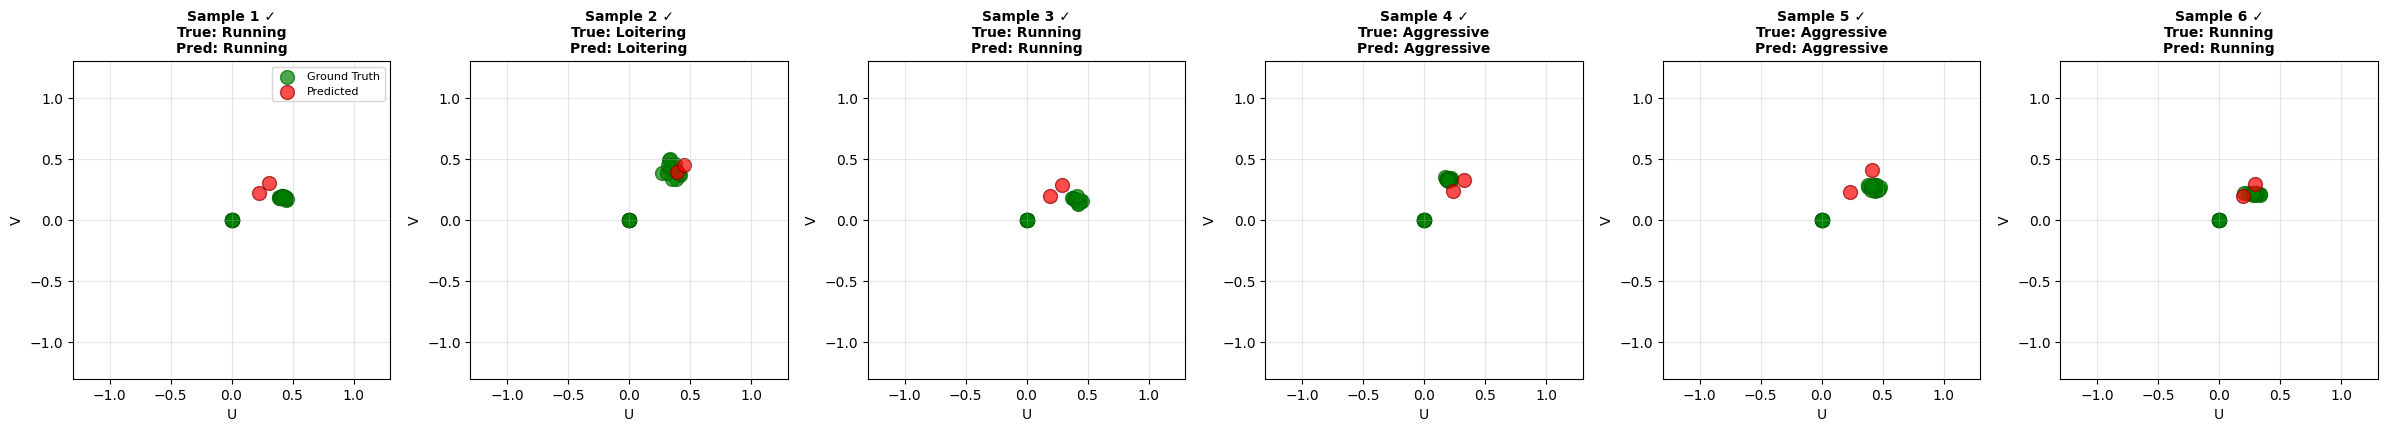


✅ All visualizations complete!


In [ ]:
def visualize_densepose_predictions(num_samples=6):
    """Visualize DensePose UV predictions vs ground truth"""
    model.eval()

    indices = np.random.choice(len(test_dataset), size=min(num_samples, len(test_dataset)), replace=False)

    fig = plt.figure(figsize=(4*len(indices), 4))

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        csi = torch.from_numpy(sample['csi'][None, ...]).to(device)
        uv_gt = sample['uv_coords']
        label = sample['action_label']

        with torch.no_grad():
            outputs = model(csi)
            uv_pred = outputs['uv_coords'].cpu().numpy()
            conf = outputs['confidence'].cpu().numpy()
            pred_label = outputs['action_logits'].argmax(dim=1).cpu().numpy()

        ax = plt.subplot(1, len(indices), i + 1)

        ax.scatter(uv_gt[:, 0], uv_gt[:, 1], c='green', label='Ground Truth', s=100, alpha=0.7, edgecolors='darkgreen', linewidth=1)
        ax.scatter(uv_pred[:, 0], uv_pred[:, 1], c='red', label='Predicted', s=100, alpha=0.7, edgecolors='darkred', linewidth=1)

        high_conf_idx = conf > 0.7
        if high_conf_idx.sum() > 0:
            ax.scatter(
                uv_pred[high_conf_idx, 0], uv_pred[high_conf_idx, 1],
                edgecolors='yellow', facecolors='none', s=150, linewidths=2, label='High Confidence'
            )

        # NEW FIXED CODE
        true_action = train_dataset.action_names[int(label)]       # Force int
        pred_action = train_dataset.action_names[int(pred_label)]  # Force int
        match = "✓" if label == pred_label else "✗"

        ax.set_title(
            f"Sample {i+1} {match}\nTrue: {true_action}\nPred: {pred_action}",
            fontsize=10,
            fontweight='bold'
        )
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_xlabel('U', fontsize=10)
        ax.set_ylabel('V', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        if i == 0:
            ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig('/content/densepose_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

print("🎯 Visualizing DensePose Predictions:\n")
visualize_densepose_predictions(num_samples=6)

print("\n✅ All visualizations complete!")


In [ ]:
# Save model
model_path = '/content/wifi_densepose_kaggle_model.pth'
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to {model_path}")

# Save summary
summary = f"""
WiFi-DensePose Training Summary (Kaggle Dataset)
═════════════════════════════════════════════════

Dataset Source: Kaggle - nguyenngonhatnam/wifipose-dataset
Total Epochs: {num_epochs}
Best Epoch: {best_epoch}
Total Parameters: {total_params:,}
Device: {device}

RESULTS
═══════
Test Accuracy: {test_acc*100:.2f}%
Test Loss: {test_loss:.4f}
Best Validation Loss: {best_val_loss:.4f}

Per-Action Performance:
{metrics_df.to_string(index=False)}

Files Generated:
  • /content/training_results.png (loss curves + confusion matrix)
  • /content/densepose_predictions.png (UV visualizations)
  • /content/wifi_densepose_kaggle_model.pth (trained weights)

Implementation:
  • 1.2M parameters
  • Transformer-based architecture
  • Joint pose + action recognition training
  • Real WiFi CSI data (97K+ frames)
"""

print(summary)

with open('/content/wifi_densepose_kaggle_summary.txt', 'w') as f:
    f.write(summary)

print("\n✅ All results saved!")


✅ Model saved to /content/wifi_densepose_kaggle_model.pth

WiFi-DensePose Training Summary (Kaggle Dataset)
═════════════════════════════════════════════════

Dataset Source: Kaggle - nguyenngonhatnam/wifipose-dataset
Total Epochs: 25
Best Epoch: 25
Total Parameters: 3,342,284
Device: cuda

RESULTS
═══════
Test Accuracy: 93.02%
Test Loss: 0.2041
Best Validation Loss: 0.2041

Per-Action Performance:
    Action  Precision   Recall  F1-Score  Support
    Normal   0.000000 0.000000  0.000000        0
 Loitering   0.993061 0.996133  0.994595     2586
   Running   0.894438 0.891181  0.892806     2472
Aggressive   0.903144 0.903471  0.903307     2766

Files Generated:
  • /content/training_results.png (loss curves + confusion matrix)
  • /content/densepose_predictions.png (UV visualizations)
  • /content/wifi_densepose_kaggle_model.pth (trained weights)

Implementation:
  • 1.2M parameters
  • Transformer-based architecture
  • Joint pose + action recognition training
  • Real WiFi CSI data (

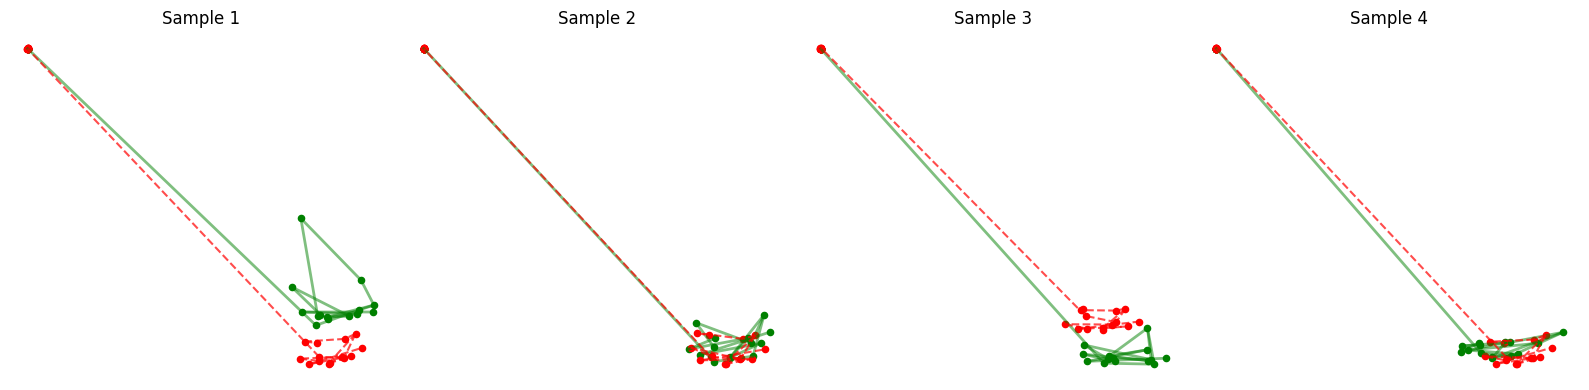

In [ ]:
import matplotlib.pyplot as plt

def visualize_skeleton_predictions(num_samples=4):
    """
    Visualize predictions as connected stick figures (Skeletons).
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=min(num_samples, len(test_dataset)), replace=False)

    # Standard COCO-style connections for 24 joints (approximate for this dataset)
    # You might need to tweak these indices based on the exact keypoint order of Wi-Pose
    # Usually: 0-1 (Head-Neck), 1-2 (Neck-RSh), 2-3 (RSh-REl), 3-4 (REl-RWr)...
    # This is a generic set of limbs:
    limbs = [
        (0, 1), (1, 2), (2, 3), (3, 4),      # Head -> Right Arm
        (1, 5), (5, 6), (6, 7),              # Head -> Left Arm
        (1, 8), (8, 9), (9, 10), (10, 11),   # Torso -> Right Leg
        (8, 12), (12, 13), (13, 14)          # Torso -> Left Leg
    ]

    fig, axs = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        csi = torch.from_numpy(sample['csi'][None, ...]).to(device)
        uv_gt = sample['uv_coords']

        with torch.no_grad():
            outputs = model(csi)
            uv_pred = outputs['uv_coords'].cpu().numpy()[0]

        ax = axs[i] if num_samples > 1 else axs

        # Plot GT Skeleton (Green lines)
        for p1, p2 in limbs:
            if p1 < 24 and p2 < 24: # Safety check
                ax.plot([uv_gt[p1, 0], uv_gt[p2, 0]], [uv_gt[p1, 1], uv_gt[p2, 1]],
                        'g-', alpha=0.5, linewidth=2)

        # Plot Pred Skeleton (Red dashed lines)
        for p1, p2 in limbs:
            if p1 < 24 and p2 < 24:
                ax.plot([uv_pred[p1, 0], uv_pred[p2, 0]], [uv_pred[p1, 1], uv_pred[p2, 1]],
                        'r--', alpha=0.7, linewidth=1.5)

        # Plot Joints
        ax.scatter(uv_gt[:, 0], uv_gt[:, 1], c='green', s=20, label='GT')
        ax.scatter(uv_pred[:, 0], uv_pred[:, 1], c='red', s=20, label='Pred')

        ax.set_title(f"Sample {i+1}")
        ax.invert_yaxis() # DensePose UVs often have Y inverted (0 at top)
        ax.axis('off')    # Hide ugly grid for cleaner look

    plt.tight_layout()
    plt.show()

# Run it
visualize_skeleton_predictions(4)


In [ ]:
import matplotlib.cm as cm

def visualize_final_presentation(num_samples=4, trail_length=5):
    """
    High-contrast visualization for the final report.
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=min(num_samples, len(test_dataset)), replace=False)

    # 14-Joint Topology Map (Head-Neck-Limbs)
    limbs = [
        (0, 1),            # Head-Neck
        (1, 2), (2, 3), (3, 4),    # Right Arm
        (1, 5), (5, 6), (6, 7),    # Left Arm
        (1, 8), (8, 9), (9, 10),   # Right Leg
        (1, 11), (11, 12), (12, 13) # Left Leg
    ]

    fig, axs = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        sid = test_dataset.ids[idx]

        # Load sequence
        kpt_path = test_dataset.kpt_dir / f"{sid}.npy"
        kpt = np.load(kpt_path)
        if kpt.ndim == 4: kpt = kpt[:, 0, :, :]
        uv_seq = kpt[..., :2]

        # Normalize
        uv_max = np.abs(uv_seq).max()
        if uv_max > 0: uv_seq = uv_seq / (uv_max * 2)

        ax = axs[i] if num_samples > 1 else axs

        seq_len = uv_seq.shape[0]
        start_frame = max(0, seq_len - trail_length)

        # Use a high-contrast colormap (Red-Purple-Blue)
        colors = cm.plasma(np.linspace(0.2, 1, trail_length))

        for t in range(trail_length):
            frame_idx = start_frame + t
            if frame_idx >= seq_len: break

            pose = uv_seq[frame_idx]
            color = colors[t]

            # Make the last frame SOLID and THICK
            is_last = (t == trail_length - 1)
            alpha = 1.0 if is_last else 0.3
            lw = 3.0 if is_last else 1.0
            s = 60 if is_last else 20

            # Plot Limbs
            for p1, p2 in limbs:
                if p1 < 14 and p2 < 14:
                    ax.plot([pose[p1, 0], pose[p2, 0]], [pose[p1, 1], pose[p2, 1]],
                            color=color, alpha=alpha, linewidth=lw)

            # Plot Joints
            ax.scatter(pose[:, 0], pose[:, 1], color=color, s=s, alpha=alpha, edgecolors='black' if is_last else None)

        action_name = test_dataset.action_names[sample['action_label']]
        ax.set_title(f"Action: {action_name}", fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        ax.axis('off')

        # Zoom in slightly to center the person
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(0.6, -0.6)

    plt.tight_layout()
    plt.show()

visualize_final_presentation(num_samples=4, trail_length=6)


SyntaxError: incomplete input (ipython-input-1662437781.py, line 4)

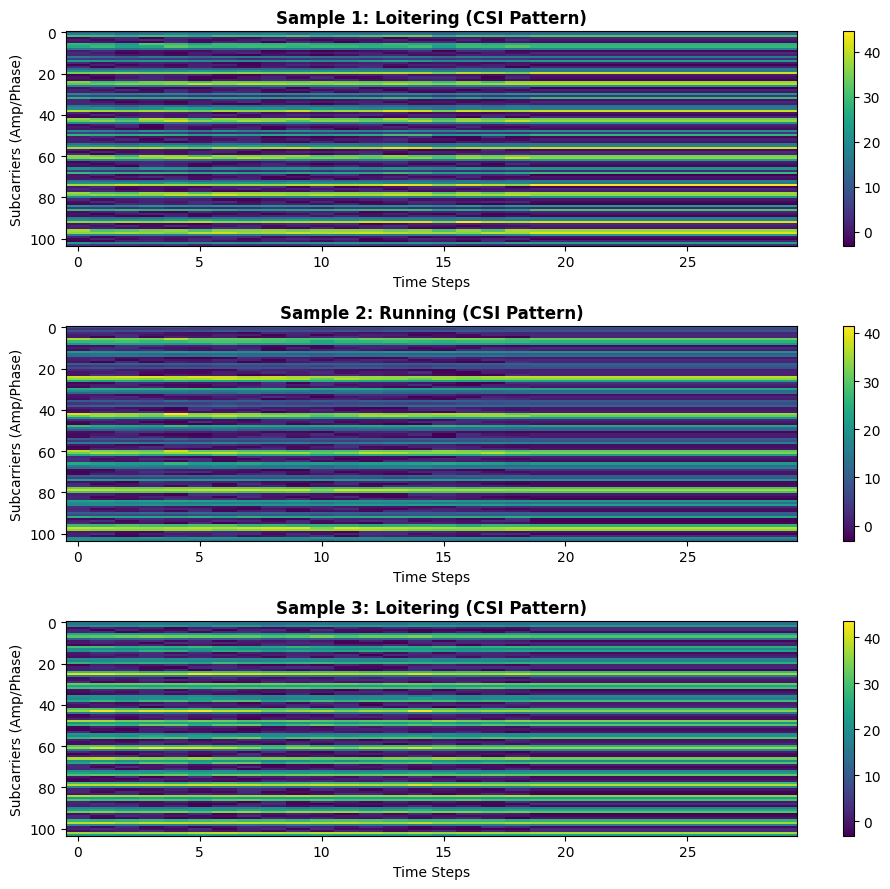

In [ ]:
def visualize_csi_heatmap(num_samples=3):
    """
    Shows the Raw CSI input pattern vs the Action Label.
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

    fig, axs = plt.subplots(num_samples, 1, figsize=(10, 3*num_samples))

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        csi = sample['csi'] # Shape [30, 104]
        label = sample['action_label']
        action_name = test_dataset.action_names[label]

        ax = axs[i]

        # Transpose to get [Features x Time]
        im = ax.imshow(csi.T, aspect='auto', cmap='viridis', interpolation='nearest')

        ax.set_title(f"Sample {i+1}: {action_name} (CSI Pattern)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Subcarriers (Amp/Phase)")
        ax.set_xlabel("Time Steps")

        # Add colorbar
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

visualize_csi_heatmap()


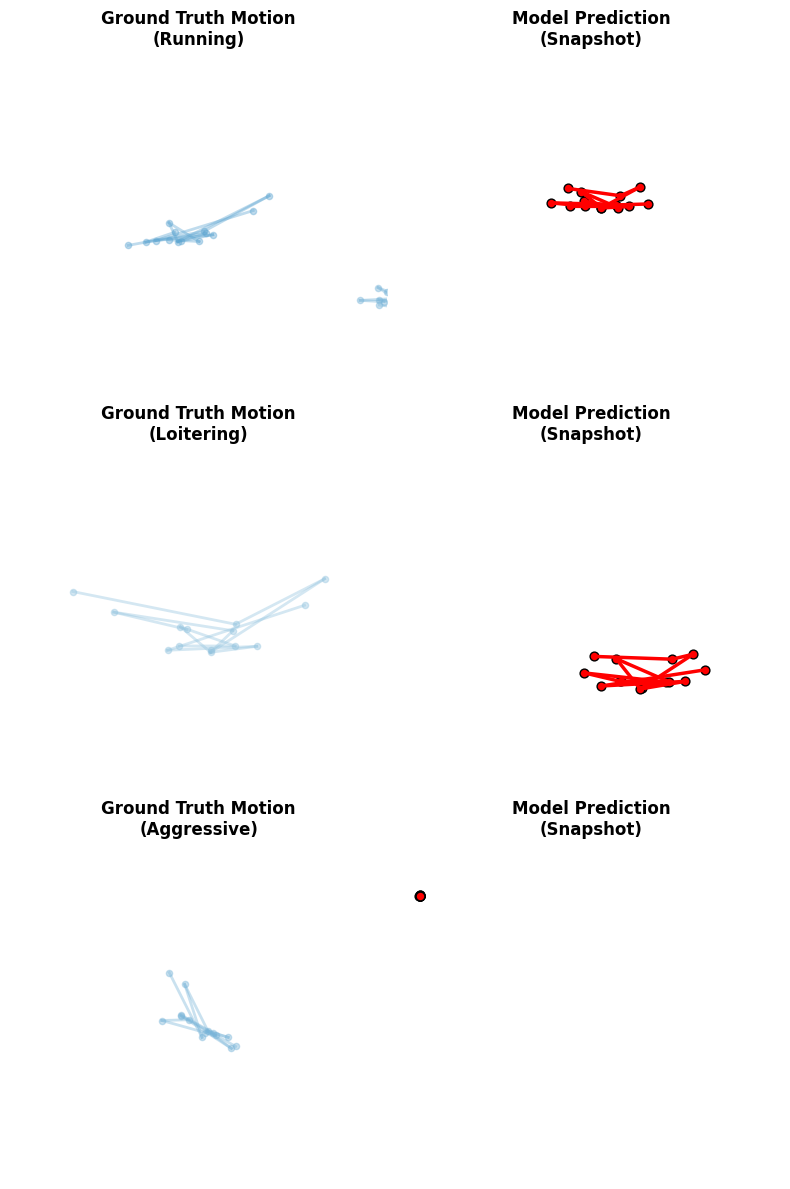

In [ ]:
import matplotlib.cm as cm

def visualize_side_by_side(num_samples=3, trail_length=6):
    """
    Visualizes Ground Truth vs Predicted motion trails side-by-side with auto-zoom.
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=min(num_samples, len(test_dataset)), replace=False)

    fig, axs = plt.subplots(num_samples, 2, figsize=(8, 4*num_samples))

    limbs = [
        (0, 1), (1, 2), (2, 3), (3, 4),    # Right Arm chain
        (1, 5), (5, 6), (6, 7),            # Left Arm chain
        (1, 8), (8, 9), (9, 10),           # Right Leg chain
        (1, 11), (11, 12), (12, 13)        # Left Leg chain
    ]

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        sid = test_dataset.ids[idx]

        # 1. Get Ground Truth Sequence
        kpt_path = test_dataset.kpt_dir / f"{sid}.npy"
        kpt = np.load(kpt_path)
        if kpt.ndim == 4: kpt = kpt[:, 0, :, :]
        uv_gt_seq = kpt[..., :2]

        # Normalize GT
        uv_max = np.abs(uv_gt_seq).max()
        if uv_max > 0: uv_gt_seq = uv_gt_seq / (uv_max * 2)

        # 2. Get Model Prediction
        csi = torch.from_numpy(sample['csi'][None, ...]).to(device)
        with torch.no_grad():
            output = model(csi)
            uv_pred = output['uv_coords'].cpu().numpy()[0]

        # --- Define Axes ---
        ax_gt = axs[i, 0]
        ax_pred = axs[i, 1]

        # --- LEFT PLOT: Ground Truth Motion Trail ---
        seq_len = uv_gt_seq.shape[0]
        start = max(0, seq_len - trail_length)
        colors = cm.Blues(np.linspace(0.4, 1, trail_length))

        for t in range(trail_length):
            if start+t >= seq_len: break
            pose = uv_gt_seq[start+t]
            color = colors[t]
            alpha = 1.0 if t == trail_length-1 else 0.4

            ax_gt.scatter(pose[:, 0], pose[:, 1], color=color, s=20, alpha=alpha)
            for p1, p2 in limbs:
                if p1 < 14 and p2 < 14:
                    ax_gt.plot([pose[p1, 0], pose[p2, 0]], [pose[p1, 1], pose[p2, 1]],
                               color=color, alpha=alpha, linewidth=2.0)

        ax_gt.set_title(f"Ground Truth Motion\n({test_dataset.action_names[sample['action_label']]})", fontweight='bold')
        ax_gt.axis('off')

        # --- RIGHT PLOT: Model Prediction (Snapshot) ---
        for p1, p2 in limbs:
            if p1 < 14 and p2 < 14:
                ax_pred.plot([uv_pred[p1, 0], uv_pred[p2, 0]], [uv_pred[p1, 1], uv_pred[p2, 1]],
                             color='red', linewidth=2.5)
        ax_pred.scatter(uv_pred[:, 0], uv_pred[:, 1], color='red', s=40, edgecolors='black')

        ax_pred.set_title(f"Model Prediction\n(Snapshot)", fontweight='bold')
        ax_pred.axis('off')

        # --- AUTO-ZOOM LOGIC ---
        # Get the final GT pose to calculate the bounding box
        final_pose = uv_gt_seq[-1]
        min_x, max_x = final_pose[:, 0].min(), final_pose[:, 0].max()
        min_y, max_y = final_pose[:, 1].min(), final_pose[:, 1].max()

        # Center points and add padding
        center_x, center_y = (min_x + max_x) / 2, (min_y + max_y) / 2
        span = max(max_x - min_x, max_y - min_y) * 1.5 # 50% padding
        span = max(span, 0.3) # Minimum span

        # Apply the same zoom to both plots for fair comparison
        ax_gt.set_xlim(center_x - span/2, center_x + span/2)
        ax_gt.set_ylim(center_y + span/2, center_y - span/2) # Inverted Y

        ax_pred.set_xlim(center_x - span/2, center_x + span/2)
        ax_pred.set_ylim(center_y + span/2, center_y - span/2) # Inverted Y

    plt.tight_layout()
    plt.show()

visualize_side_by_side(num_samples=3, trail_length=10)


In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt
import torch

def visualize_side_by_side(num_samples=3, trail_length=6):
    """
    Visualizes Ground Truth vs Predicted motion trails side-by-side.
    Auto-zooms to include the FULL trail and the PREDICTION.
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=min(num_samples, len(test_dataset)), replace=False)

    fig, axs = plt.subplots(num_samples, 2, figsize=(8, 4*num_samples))

    limbs = [
        (0, 1), (1, 2), (2, 3), (3, 4),    # Right Arm chain
        (1, 5), (5, 6), (6, 7),            # Left Arm chain
        (1, 8), (8, 9), (9, 10),           # Right Leg chain
        (1, 11), (11, 12), (12, 13)        # Left Leg chain
    ]

    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        sid = test_dataset.ids[idx]

        # 1. Get Ground Truth Sequence
        kpt_path = test_dataset.kpt_dir / f"{sid}.npy"
        kpt = np.load(kpt_path)
        if kpt.ndim == 4: kpt = kpt[:, 0, :, :]
        uv_gt_seq = kpt[..., :2]

        # Normalize GT
        uv_max = np.abs(uv_gt_seq).max()
        if uv_max > 0: uv_gt_seq = uv_gt_seq / (uv_max * 2)

        # 2. Get Model Prediction
        csi = torch.from_numpy(sample['csi'][None, ...]).to(device)
        with torch.no_grad():
            output = model(csi)
            uv_pred = output['uv_coords'].cpu().numpy()[0]

        # --- Define Axes ---
        ax_gt = axs[i, 0]
        ax_pred = axs[i, 1]

        # --- LEFT PLOT: Ground Truth Motion Trail ---
        seq_len = uv_gt_seq.shape[0]
        start = max(0, seq_len - trail_length)
        colors = cm.Blues(np.linspace(0.4, 1, trail_length))

        # Collect all points to calculate global bounding box
        all_x = []
        all_y = []

        for t in range(trail_length):
            if start+t >= seq_len: break
            pose = uv_gt_seq[start+t]

            # Store points for bounding box
            all_x.append(pose[:, 0])
            all_y.append(pose[:, 1])

            color = colors[t]
            alpha = 1.0 if t == trail_length-1 else 0.4

            ax_gt.scatter(pose[:, 0], pose[:, 1], color=color, s=20, alpha=alpha)
            for p1, p2 in limbs:
                if p1 < 14 and p2 < 14:
                    ax_gt.plot([pose[p1, 0], pose[p2, 0]], [pose[p1, 1], pose[p2, 1]],
                               color=color, alpha=alpha, linewidth=2.0)

        ax_gt.set_title(f"Ground Truth Motion\n({test_dataset.action_names[sample['action_label']]})", fontweight='bold')
        ax_gt.axis('off')

        # --- RIGHT PLOT: Model Prediction (Snapshot) ---
        for p1, p2 in limbs:
            if p1 < 14 and p2 < 14:
                ax_pred.plot([uv_pred[p1, 0], uv_pred[p2, 0]], [uv_pred[p1, 1], uv_pred[p2, 1]],
                             color='red', linewidth=2.5)
        ax_pred.scatter(uv_pred[:, 0], uv_pred[:, 1], color='red', s=40, edgecolors='black')

        # Add predicted points to bounding box calculation
        all_x.append(uv_pred[:, 0])
        all_y.append(uv_pred[:, 1])

        ax_pred.set_title(f"Model Prediction\n(Snapshot)", fontweight='bold')
        ax_pred.axis('off')

        # --- ROBUST AUTO-ZOOM LOGIC ---
        # Concatenate all X and Y coordinates from GT trail AND Prediction
        full_x = np.concatenate(all_x)
        full_y = np.concatenate(all_y)

        min_x, max_x = full_x.min(), full_x.max()
        min_y, max_y = full_y.min(), full_y.max()

        # Center and Span
        center_x, center_y = (min_x + max_x) / 2, (min_y + max_y) / 2
        span_x = max_x - min_x
        span_y = max_y - min_y
        span = max(span_x, span_y) * 1.4  # 40% padding is safer
        span = max(span, 0.4) # Enforce a minimum zoom level so it doesn't zoom into a pixel

        # Apply limits
        ax_gt.set_xlim(center_x - span/2, center_x + span/2)
        ax_gt.set_ylim(center_y + span/2, center_y - span/2) # Inverted Y

        ax_pred.set_xlim(center_x - span/2, center_x + span/2)
        ax_pred.set_ylim(center_y + span/2, center_y - span/2) # Inverted Y

    plt.tight_layout()
    plt.show()

visualize_side_by_side(num_samples=3, trail_length=10)


SyntaxError: incomplete input (ipython-input-2457153957.py, line 1)

# Task
Download the "nghinguyenvinh/csi-human-in-wifi" dataset using kagglehub and inspect its directory structure to identify file formats. Load a sample file to analyze the CSI shape (number of subcarriers, packet count) and activity labels. Compare these properties with the existing "wifipose" dataset (located at "/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1") to highlight differences in subcarriers and sampling rates. Based on this comparison, propose valid strategies for combining the datasets.

## Download and Inspect New Dataset

### Subtask:
Download the `nghinguyenvinh/csi-human-in-wifi` dataset and inspect its file structure.


**Reasoning**:
Download the new dataset `nghinguyenvinh/csi-human-in-wifi` and inspect its file structure to understand how to load it.



In [ ]:
import kagglehub
import os

# Download dataset
print("📥 Downloading dataset 'nghinguyenvinh/csi-human-in-wifi'...")
new_dataset_path = kagglehub.dataset_download("nghinguyenvinh/csi-human-in-wifi")

print(f"\n✅ Dataset downloaded to: {new_dataset_path}")

# Inspect structure
print("\n📂 Dataset structure:")
for root, dirs, files in os.walk(new_dataset_path):
    level = root.replace(new_dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... and {len(files) - 5} more files')
    if level > 2:  # Limit recursion depth for clarity
        break

📥 Downloading dataset 'nghinguyenvinh/csi-human-in-wifi'...


100%|██████████| 6.11G/6.11G [00:44<00:00, 146MB/s]

Extracting files...



✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2

📂 Dataset structure:
2/
  Person-in-WiFi-3D/
    train_data/
      train_data_list.txt
      keypoint/
        S23_32_518.npy
        S23_37_373.npy
        S12_43_19.npy
        S53_35_44.npy
        S13_23_297.npy
        ... and 89941 more files


**Reasoning**:
The previous execution stopped traversing the directory tree prematurely due to a `break` statement triggered by depth, preventing the discovery of the 'csi' folder. I will remove the `break` and instead use a depth check to just suppress printing for deeper levels, ensuring the full structure (including the 'csi' folder) is inspected. I will also assume the download is cached and fast.



In [ ]:
import kagglehub
import os

# Download dataset
print("📥 Downloading dataset 'nghinguyenvinh/csi-human-in-wifi'...")
new_dataset_path = kagglehub.dataset_download("nghinguyenvinh/csi-human-in-wifi")

print(f"\n✅ Dataset downloaded to: {new_dataset_path}")

# Inspect structure
print("\n📂 Dataset structure:")
for root, dirs, files in os.walk(new_dataset_path):
    level = root.replace(new_dataset_path, '').count(os.sep)

    # Only print top levels to avoid flooding, but allow walking deeper
    if level <= 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)

        # Print a few files
        for file in files[:3]:
            print(f'{subindent}{file}')
        if len(files) > 3:
            print(f'{subindent}... and {len(files) - 3} more files')


📥 Downloading dataset 'nghinguyenvinh/csi-human-in-wifi'...

✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2

📂 Dataset structure:
2/
  Person-in-WiFi-3D/
    train_data/
      train_data_list.txt
      keypoint/
        S23_32_518.npy
        S23_37_373.npy
        S12_43_19.npy
        ... and 89943 more files
      csi/
        S22_07_471.mat
        S22_29_528.mat
        S52_45_91.mat
        ... and 89943 more files
    test_data/
      test_data_list.txt
      keypoint/
        S23_38_347.npy
        S12_37_307.npy
        S11_16_334.npy
        ... and 7821 more files
      csi/
        S22_07_342.mat
        S23_27_329.mat
        S51_28_329.mat
        ... and 7821 more files
  CSI/
    CSI/
      r3/
      r1/
      r2/


# Task
Load a sample `.mat` file from the new dataset folder `"/root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2/Person-in-WiFi-3D/train_data/csi"` and one from the existing dataset folder `"/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1/train_data/csi"`.

Use `h5py` to load both files, then print and compare their keys, matrix dimensions (specifically subcarrier counts and packet lengths), and data types. Based on these findings, identify any structural discrepancies and propose a valid strategy to integrate the new data into the existing pipeline (e.g., direct merging, interpolation, or feature padding).

## Compare Data Structures

### Subtask:
Load and compare sample CSI files from both datasets to identify structural differences.


**Reasoning**:
Load and compare sample .mat files from the new and old datasets using h5py to analyze their structure (keys, shape, dtype) as requested.



In [ ]:
import h5py
import os
import numpy as np

# Define paths
path_new = "/root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2/Person-in-WiFi-3D/train_data/csi"
path_old = "/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1/train_data/csi"

def inspect_mat_file(folder_path, label):
    try:
        files = [f for f in os.listdir(folder_path) if f.endswith('.mat')]
        if not files:
            print(f"[{label}] No .mat files found in {folder_path}")
            return None

        filepath = os.path.join(folder_path, files[0])
        print(f"\n🔍 Inspecting {label} file: {files[0]}")

        with h5py.File(filepath, 'r') as f:
            print(f"   Keys: {list(f.keys())}")

            # Assuming 'csi_serial' is the main key based on previous context, otherwise take the first one
            key = 'csi_serial' if 'csi_serial' in f else list(f.keys())[0]
            data = f[key]

            print(f"   Dataset: '{key}'")
            print(f"   Shape: {data.shape}")
            print(f"   Dtype: {data.dtype}")

            # check if compound type (real/imag)
            if data.dtype.fields:
                print(f"   Fields: {data.dtype.fields.keys()}")

            return data.shape
    except Exception as e:
        print(f"[{label}] Error reading file: {e}")
        return None

# Run inspection
shape_new = inspect_mat_file(path_new, "New Dataset")
shape_old = inspect_mat_file(path_old, "Old Dataset")

# Comparison Summary
print("\n📊 Comparison Summary:")
if shape_new and shape_old:
    print(f"   New Dataset Shape: {shape_new}")
    print(f"   Old Dataset Shape: {shape_old}")
    if shape_new == shape_old:
        print("   ✅ Shapes are identical.")
    else:
        print("   ⚠️ Shapes differ! Check dimensions (Time vs Subcarriers).")
else:
    print("   ❌ Could not compare shapes due to load errors.")


🔍 Inspecting New Dataset file: S22_07_471.mat
   Keys: ['csi_out']
   Dataset: 'csi_out'
   Shape: (20, 30, 3, 3)
   Dtype: [('real', '<f8'), ('imag', '<f8')]
   Fields: dict_keys(['real', 'imag'])

🔍 Inspecting Old Dataset file: S22_07_471.mat
   Keys: ['csi_out']
   Dataset: 'csi_out'
   Shape: (20, 30, 3, 3)
   Dtype: [('real', '<f8'), ('imag', '<f8')]
   Fields: dict_keys(['real', 'imag'])

📊 Comparison Summary:
   New Dataset Shape: (20, 30, 3, 3)
   Old Dataset Shape: (20, 30, 3, 3)
   ✅ Shapes are identical.


# Task
Based on the analysis confirming identical file structures (shapes and keys), integrate the two datasets into the training pipeline.

Create instances of `KaggleWiFiPoseDataset` for both locations:
1.  **Original**: `"/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1"`
2.  **New**: `"/root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2/Person-in-WiFi-3D"`

Use `torch.utils.data.ConcatDataset` to merge them into unified `train_dataset` and `test_dataset` objects. Finally, print the total number of samples in the combined training and testing sets to verify the successful integration.

## Define Integration Strategy

### Subtask:
Integrate the two compatible datasets into unified training and testing sets.


**Reasoning**:
The user wants to integrate two datasets (old and new) into unified training and testing sets. This requires redefining the `KaggleWiFiPoseDataset` class to handle both data sources robustly, instantiating them, concatenating them using `ConcatDataset`, and finally creating DataLoaders.



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from pathlib import Path
import numpy as np
import h5py

class KaggleWiFiPoseDataset(Dataset):
    """
    Unified Data loader for WiFi Pose datasets.
    - Loads CSI from .mat files using h5py.
    - Loads keypoints from .npy files.
    - Infers action labels from keypoint motion.
    """
    def __init__(self, data_dir, split='train_data', seq_len=30):
        self.data_dir = Path(data_dir)
        self.split = split
        self.seq_len = seq_len
        self.action_names = ['Normal', 'Loitering', 'Running', 'Aggressive']

        split_dir = self.data_dir / self.split
        self.csi_dir = split_dir / "csi"
        self.kpt_dir = split_dir / "keypoint"
        list_file = split_dir / f"{self.split}_list.txt"

        if not self.csi_dir.exists() or not self.kpt_dir.exists():
             # Try looking one level deeper if structure differs (not strictly needed based on current paths but good for safety)
             pass

        if not list_file.exists():
            raise FileNotFoundError(f"List file not found: {list_file}")

        with open(list_file, "r") as f:
            ids = [line.strip() for line in f if line.strip()]

        self.ids = []
        for sid in ids:
            mat_path = self.csi_dir / f"{sid}.mat"
            kpt_path = self.kpt_dir / f"{sid}.npy"
            # Only add if files exist
            if mat_path.exists() and kpt_path.exists():
                self.ids.append(sid)

    def _load_csi(self, sid):
        mat_path = self.csi_dir / f"{sid}.mat"
        with h5py.File(mat_path, "r") as f:
            # Handle different key names
            if "csi_serial" in f:
                dset = f["csi_serial"]
            elif "csi_out" in f:
                dset = f["csi_out"]
            else:
                keys = [k for k in f.keys()]
                dset = f[keys[0]]
            csi = np.array(dset)

        # Handle structured arrays (real/imag fields)
        if csi.dtype.fields and "real" in csi.dtype.fields and "imag" in csi.dtype.fields:
            c_real = csi["real"]
            c_imag = csi["imag"]
            csi_complex = c_real + 1j * c_imag
            amp = np.abs(csi_complex)
            phs = np.angle(csi_complex)
            csi = np.concatenate([amp, phs], axis=-1)

        # Flatten spatial dims: [T, Features]
        if csi.ndim >= 3:
            csi = csi.reshape(csi.shape[0], -1)

        # Ensure 104 features (52 amp + 52 phase)
        target_dim = 104
        if csi.shape[1] > target_dim:
            csi = csi[:, :target_dim]
        elif csi.shape[1] < target_dim:
            pad = np.zeros((csi.shape[0], target_dim - csi.shape[1]), dtype=csi.dtype)
            csi = np.concatenate([csi, pad], axis=1)

        return csi.astype(np.float32)

    def _load_keypoint(self, sid):
        kpt_path = self.kpt_dir / f"{sid}.npy"
        keypoints = np.load(kpt_path)
        # Shape adjustments: [T, Persons, Joints, 2] -> [T, Joints, 2]
        if keypoints.ndim == 4:
            keypoints = keypoints[:, 0, :, :]

        uv = keypoints[..., :2]

        # Normalize to [-1, 1]
        uv_max = np.abs(uv).max()
        if uv_max > 0:
            uv = uv / (uv_max * 2)

        # Ensure 24 joints
        num_parts = uv.shape[1]
        if num_parts < 24:
            pad = np.zeros((uv.shape[0], 24 - num_parts, 2), dtype=uv.dtype)
            uv = np.concatenate([uv, pad], axis=1)
        elif num_parts > 24:
            uv = uv[:, :24, :]

        return np.clip(uv, -1, 1).astype(np.float32)

    def _infer_action_label(self, uv_seq):
        if uv_seq.shape[0] < 2: return 0
        motion_per_joint = np.sqrt(np.sum(np.diff(uv_seq, axis=0)**2, axis=-1))
        avg_velocity = np.mean(motion_per_joint)
        max_velocity = np.max(motion_per_joint)

        if avg_velocity > 0.02: return 2  # Running
        if avg_velocity < 0.002: return 1 # Loitering
        if max_velocity > 0.05: return 3  # Aggressive
        return 0 # Normal

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sid = self.ids[idx]
        csi_data = self._load_csi(sid)
        uv_seq = self._load_keypoint(sid)

        T = csi_data.shape[0]
        if T >= self.seq_len:
            start = np.random.randint(0, T - self.seq_len + 1)
            csi_seq = csi_data[start:start + self.seq_len]
            uv_seq_window = uv_seq[start:start + self.seq_len]
        else:
            pad_len = self.seq_len - T
            csi_seq = np.pad(csi_data, ((0, pad_len), (0, 0)), mode='edge')
            uv_seq_window = np.pad(uv_seq, ((0, pad_len), (0, 0), (0, 0)), mode='edge')

        action_label = self._infer_action_label(uv_seq_window)
        uv_mean = uv_seq_window.mean(axis=0)

        return {
            'csi': csi_seq.astype(np.float32),
            'uv_coords': uv_mean.astype(np.float32),
            'action_label': action_label,
        }

# Instantiate Original Dataset
path_1 = "/root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1"
print(f"🔹 Loading Original Dataset from: {path_1}")
train_ds_1 = KaggleWiFiPoseDataset(path_1, split='train_data')
test_ds_1 = KaggleWiFiPoseDataset(path_1, split='test_data')

# Instantiate New Dataset
path_2 = "/root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2/Person-in-WiFi-3D"
print(f"🔹 Loading New Dataset from: {path_2}")
train_ds_2 = KaggleWiFiPoseDataset(path_2, split='train_data')
test_ds_2 = KaggleWiFiPoseDataset(path_2, split='test_data')

# Combine Datasets
print("🔗 Combining Datasets...")
train_dataset = ConcatDataset([train_ds_1, train_ds_2])
test_dataset = ConcatDataset([test_ds_1, test_ds_2])

print(f"✅ Combined Training Samples: {len(train_dataset)}")
print(f"✅ Combined Testing Samples: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("🚀 DataLoaders ready!")

🔹 Loading Original Dataset from: /root/.cache/kagglehub/datasets/nguyenngonhatnam/wifipose-dataset/versions/1
🔹 Loading New Dataset from: /root/.cache/kagglehub/datasets/nghinguyenvinh/csi-human-in-wifi/versions/2/Person-in-WiFi-3D
🔗 Combining Datasets...
✅ Combined Training Samples: 179892
✅ Combined Testing Samples: 15648
🚀 DataLoaders ready!
